In [1]:
import sys
import importlib

def install_if_missing(package, import_name=None):
    """Install a package only if it's not already installed"""
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package}...")
        !{sys.executable} -m pip install {package} -q
        print(f"{package} installed ✅")
    else:
        print(f"{package} already available ✅")

install_if_missing("datasets")
install_if_missing("tqdm")
install_if_missing("ipywidgets")

datasets already available ✅
tqdm already available ✅
ipywidgets already available ✅


In [2]:
# Imports
import os

import re
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam

from torchvision import transforms
from datasets import load_dataset
from tqdm import tqdm

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version : 2.3.1
Device          : cpu


In [3]:
# Load dataset
dataset = load_dataset("jiovine/pixel-art-nouns")['train']

print(f"Number of samples: {len(dataset)}")
print(f"Features: {dataset.features}")

Number of samples: 49859
Features: {'image': Image(mode=None, decode=True), 'text': Value('string')}


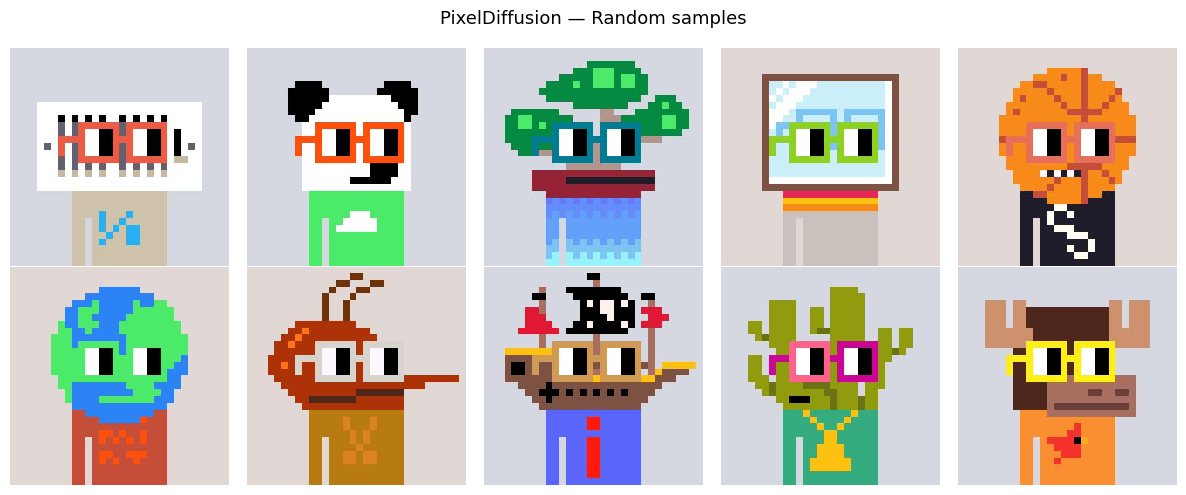

In [4]:
# Display random pixel art from the dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

indices = random.sample(range(len(dataset)), 10)

for i, ax in enumerate(axes):
    sample = dataset[indices[i]]
    img = sample['image']
    
    ax.imshow(img, interpolation='nearest')
    ax.axis('off')

plt.suptitle("PixelDiffusion — Random samples", fontsize=13)
plt.tight_layout()
plt.show()

# Tokenization
Let's build a custom tokenizer

In [5]:
# Extract all the text from the dataset
texts = [sample['text'] for sample in dataset]

In [6]:
# Definition of the tokenizer
def tokenize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s-]', '', text)
    text = text.replace('-', ' - ')
    return text.split()

print(tokenize_text(texts[0]))

['a', 'character', 'with', 'square', 'black', 'glasses', 'a', 'hotdog', '-', 'shaped', 'head', 'and', 'a', 'peachy', '-', 'colored', 'body', 'on', 'a', 'warm', 'background']


In [7]:
# Build the vocab
word_counts = Counter()
for text in texts:
    word_counts.update(tokenize_text(text))

special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']

vocab = special_tokens + [word for word, count in word_counts.most_common()]

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"Vocabulary size : {len(vocab)}")
print(f"Most common words : {word_counts.most_common(10)}")

Vocabulary size : 316
Most common words : [('a', 199436), ('-', 100538), ('and', 58531), ('with', 52032), ('character', 49859), ('square', 49859), ('shaped', 49859), ('head', 49859), ('colored', 49859), ('body', 49859)]


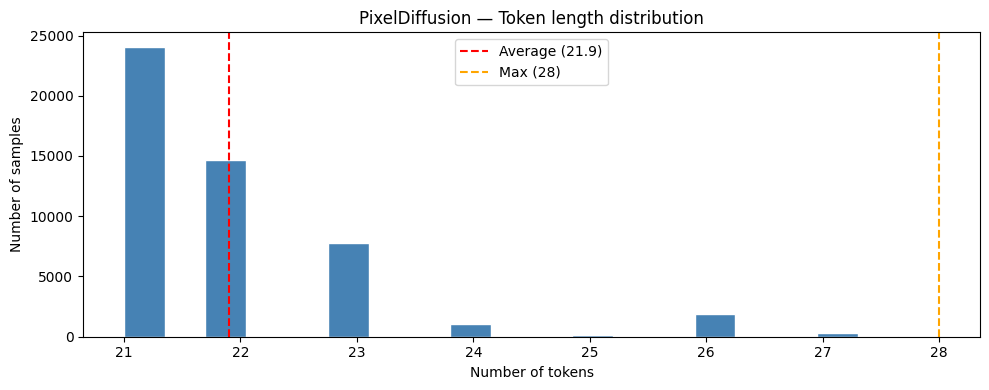

In [8]:
# Let's see the token length distribution
token_lengths = [len(tokenize_text(text)) for text in texts]

avg_len = sum(token_lengths) / len(token_lengths)

# Histogram
plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=20, color='steelblue', edgecolor='white')
plt.axvline(avg_len, color='red', linestyle='--', label=f'Average ({avg_len:.1f})')
plt.axvline(max(token_lengths), color='orange', linestyle='--', label=f'Max ({max(token_lengths)})')
plt.xlabel("Number of tokens")
plt.ylabel("Number of samples")
plt.title("PixelDiffusion — Token length distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Encode and decode function
MAX_LEN = 28 + 2

def encode(text, max_len=MAX_LEN):
    tokens = tokenize_text(text)
    ids = [word2idx['<BOS>']]
    ids += [word2idx.get(t, word2idx['<UNK>']) for t in tokens]
    ids += [word2idx['<EOS>']]
    # Pad or truncate
    ids = ids[:max_len]
    ids += [word2idx['<PAD>']] * (max_len - len(ids))
    return ids

def decode(ids):
    words = [idx2word[i] for i in ids 
             if i not in [word2idx['<PAD>'], word2idx['<BOS>'], word2idx['<EOS>']]]
    return ' '.join(words)

In [10]:
sample_text = texts[0]
encoded = encode(sample_text)
decoded = decode(encoded)

print(f"\nOriginal : {sample_text}")
print(f"Encoded  : {encoded}")
print(f"Decoded  : {decoded}")


Original : a character with square black glasses, a hotdog-shaped head and a peachy-colored body on a warm background
Encoded  : [2, 4, 8, 7, 9, 22, 16, 4, 138, 5, 10, 11, 6, 4, 31, 5, 12, 13, 14, 4, 17, 15, 3, 0, 0, 0, 0, 0, 0, 0]
Decoded  : a character with square black glasses a hotdog - shaped head and a peachy - colored body on a warm background


# Text Encoder

The aim now is to create a text encoder that will project the initial sentence into a higher and richer dimensional embedding. This embedding will later be injected into the U-Net via Cross-Attention to condition the image generation on the text description.

## Architecture

The Text Encoder is a stack of Transformer Encoder blocks :
```
tokens (B, seq_len)
        │
        ▼
Token Embedding + Positional Embedding
        │
        ▼
Transformer Block x N_trans

        │
        ▼
LayerNorm
        │
        ▼
text embeddings (B, seq_len, dim)
```

## Token + Positional Embedding

Each token is first projected into a dense vector of dimension $d$, then a positional embedding is added to encode the order of the words in the sentence :

$$x_i = \text{TokenEmb}(t_i) + \text{PosEmb}(i)$$

Where $t_i$ is the $i$-th token and $i$ is its position in the sequence. Without the positional embedding, the model would treat the sentence as a bag of words with no notion of order.

## Self-Attention

Inside each Transformer block, Self-Attention allows every token to attend to every other token in the sequence. This allows the model to learn rich associations between tokens.

## Feed Forward

After attention, each token passes through a small Feed Forward network, where the hidden dimension is expanded by a factor of 4 before being projected back. This allows the network to learn non-linear feature transformations on top of the attention output.

## Residual connections + LayerNorm

Each sub-block (attention and feed forward) uses Pre-Norm with a residual connection, This stabilizes training and prevents gradient vanishing.

## Output

The Text Encoder outputs a sequence of contextual embeddings of shape $(B, \text{seq\_len}, d)$ : one vector per token, enriched with the context of the full sentence. These embeddings will be used as Keys and Values in the Cross-Attention of the U-Net.

In [11]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads=4, ff_mult=4):
        super().__init__()

        # Self Attention
        self.norm1   = nn.LayerNorm(dim)
        self.attn    = nn.MultiheadAttention(dim, n_heads, batch_first=True)

        # MLP/Feed Forward
        self.norm2   = nn.LayerNorm(dim)
        self.ff      = nn.Sequential(
            nn.Linear(dim, dim * ff_mult),
            nn.GELU(),
            nn.Linear(dim * ff_mult, dim)
        )

    def forward(self, x, padding_mask=None):
        # Attention
        h = self.norm1(x)
        attn_out, _ = self.attn(h, h, h, key_padding_mask=padding_mask)
        # Residual
        x  = x + attn_out

        # Feed Forward + Residual
        x = x + self.ff(self.norm2(x))
        return x

In [12]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, dim=128, n_layers=4, n_heads=4, max_len=28):
        """
        vocab_size : size of your tokenizer vocabulary
        dim        : embedding dimension
        n_layers   : number of transformer blocks
        n_heads    : number of attention heads
        max_len    : maximum sequence length
        """
        super().__init__()

        self.dim     = dim

        # Embedding (Pos + Token)
        # Each token is projected into a space of dimension dim
        self.token_emb = nn.Embedding(vocab_size, dim, padding_idx=0)
        # Reguarding the position of the token he is also projected into a space of dimension dim
        self.pos_emb  = nn.Embedding(max_len, dim)

        # Transformersblocks
        self.blocks = nn.ModuleList([
            TransformerBlock(dim, n_heads) for _ in range(n_layers)
        ])

        # Norm
        self.norm = nn.LayerNorm(dim)

    def forward(self, tokens, padding_mask=None):
        """
        tokens       : (B, seq_len) token ids
        padding_mask : (B, seq_len) True where padding
        returns      : (B, seq_len, dim) text embeddings
        """
        B, seq_len = tokens.shape

        # Embedding
        # To get the positions of each tokens
        positions = torch.arange(seq_len, device=tokens.device).unsqueeze(0)  # (1, seq_len)

        # Compute the embedding
        x = self.token_emb(tokens) + self.pos_emb(positions) # (B, seq_len, dim)

        # Transformers block
        for block in self.blocks:
            x = block(x, padding_mask) # to not influence attetion 

        return self.norm(x)   # (B, seq_len, dim)

In [13]:
# Parameters
T = 1000 # if T is big, we can train the model to inverse each transformation
beta_start = 1e-4
beta_end = 0.02

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = (1 - betas).to(device)
alpha_bars = torch.cumprod(alphas, dim=0).to(device)

print(f"Running on : {device}")

Running on : cpu


In [14]:
# Let's create the function that add noise
def add_noise(x0,t):
    # Compute the noise
    noise = torch.randn_like(x0)
    # Get the wanted alpha bar
    ab = alpha_bars[t].view(-1, 1, 1, 1)
    # Compute xt
    x_t = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    return x_t, noise

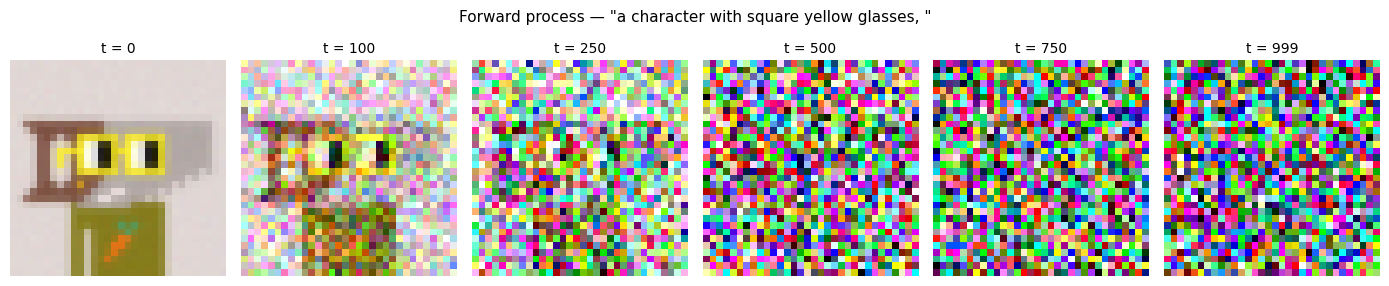

In [15]:
# Load one sample
idx = random.randint(0, len(dataset) - 1)
sample = dataset[idx]
img = sample['image']
label  = sample['text']

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

x0 = transform(img).unsqueeze(0).to(device)

# Different timesteps
timesteps = [0, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(timesteps), figsize=(14, 3))

for ax, t in zip(axes, timesteps):
    t_tensor    = torch.tensor([t]).to(device)  # ← send to device
    x_t, _      = add_noise(x0, t_tensor)

    # Denormalize for display [-1,1] → [0,1]
    img_display = (x_t.squeeze(0).cpu().permute(1, 2, 0).numpy() + 1) / 2  # ← .cpu() before .numpy()
    img_display = np.clip(img_display, 0, 1)

    ax.imshow(img_display, interpolation='nearest')
    ax.set_title(f't = {t}', fontsize=10)
    ax.axis('off')

plt.suptitle(f'Forward process — "{label[:40]}"', fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
vocab_size = len(word2idx)
text_encoder = TextEncoder(vocab_size=vocab_size, dim=128, n_layers=4, max_len=MAX_LEN)

sample_texts  = [dataset[i]['text'] for i in range(4)]
encoded = [encode(t) for t in sample_texts]
tokens = torch.tensor(encoded) # (4, 32)
padding_mask = (tokens == word2idx['<PAD>'])  # (4, 32)

with torch.no_grad():
    text_emb = text_encoder(tokens, padding_mask)

print(f"Input shape : {tokens.shape}")      # (4, 32)
print(f"Output shape : {text_emb.shape}")    # (4, 32, 128)
print(f"Text Encoder params : {sum(p.numel() for p in text_encoder.parameters()):,}")

Input shape : torch.Size([4, 30])
Output shape : torch.Size([4, 30, 128])
Text Encoder params : 837,632


# Cross-Attention

The Cross-Attention block is the bridge between the text and the image. It injects the 
text embeddings produced by the Text Encoder into the U-Net, allowing the denoising 
process to be conditioned on the text description.

## Architecture
```
x (image features) : (B, H*W, query_dim)
context (text emb) : (B, seq_len, context_dim)


LayerNorm(x)     LayerNorm(context)
        │                 │
        ▼                 ▼
      Q proj           K, V proj
        │                 │
        └────────┬────────┘
                 ▼
    scaled_dot_product_attention(Q, K, V)
                 │
                 ▼
           Merge heads
                 │
                 ▼
          Output projection
                 │
                 + residual (x)
                 │
                 ▼

output : (B, H*W, query_dim)
```

## Queries, Keys and Values

Cross-Attention uses two different sources :

$$Q = W_Q \cdot x_{\text{image}} \qquad K = W_K \cdot x_{\text{text}} \qquad V = W_V \cdot x_{\text{text}}$$

The image features ask the questions (Queries), and the text embeddings provide the answers (Keys and Values). This is how each spatial position in the image learns to align with the relevant parts of the text description.

## Attention

The attention scores are computed between each image spatial position and each text token :

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The scores matrix has shape $(B, n\_heads, H \times W, \text{seq\_len})$ 

## Residual connection

A residual connection is added after the attention :

$$\text{output} = \text{Attention}(Q, K, V) + x_{\text{image}}$$

This ensures the image features are enriched with text information rather than replaced by it.

## Output

The Cross-Attention outputs image features of the same shape as the input $(B, H \times W, d)$, now enriched with the text context. These features are then passed to the second ResBlock of the bottleneck to continue the denoising process.

In [17]:
class CrossAttention(nn.Module):
    def __init__(self, query_dim, context_dim, n_heads=4):
        """
        query_dim   : dimension of image features (from U-Net)
        context_dim : dimension of text embeddings (from Text Encoder)
        n_heads     : number of attention heads
        """
        super().__init__()
        assert query_dim % n_heads == 0, "query_dim must be divisible by n_heads"

        self.n_heads = n_heads
        self.head_dim = query_dim // n_heads
        self.scale = self.head_dim  -0.5

        # Normalization
        self.norm_image = nn.LayerNorm(query_dim)
        self.norm_text = nn.LayerNorm(context_dim)

        # Q from image, K and V from text
        self.q_proj = nn.Linear(query_dim, query_dim)
        self.k_proj = nn.Linear(context_dim, query_dim)
        self.v_proj = nn.Linear(context_dim, query_dim)

        # Output
        self.out_proj = nn.Linear(query_dim, query_dim)

    def forward(self, x, context):
        """
        x       : (B, H*W, query_dim)   image features
        context : (B, seq_len, context_dim) text embeddings
        returns : (B, H*W, query_dim)
        """

        # Get the shape
        B, HW, _ = x.shape
        _, seq_len, _ = context.shape

        # Normalize
        x_norm = self.norm_image(x)
        ctx_norm = self.norm_text(context)

        # Compute Q, K, V 
        q = self.q_proj(x_norm) # (B, H*W, query_dim)

        # projection of context_dim to query_dim
        k = self.k_proj(ctx_norm) # (B, seq_len, query_dim)
        v = self.v_proj(ctx_norm) # (B, seq_len, query_dim)

        # Reshape
        q = q.view(B, HW,self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, HW, head_dim)
        k = k.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, seq_len, head_dim)
        v = v.view(B, seq_len, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, seq_len, head_dim)

        # Scaled dot-product attention
        out = F.scaled_dot_product_attention(q, k, v) # (B, n_heads, HW, head_dim)

        # Merge heads
        out = out.transpose(1, 2).contiguous().view(B, HW, -1) # (B, HW, query_dim)

        # Output + residual
        return self.out_proj(out) + x # (B, H*W, query_dim)

In [18]:
cross_attn = CrossAttention(query_dim=128, context_dim=128, n_heads=4)

# Fake image
x  = torch.randn(4, 16,  128) # (B, H*W, query_dim)

# Fake context
context = torch.randn(4, 28, 128) # (B, seq_len, context_dim)

output = cross_attn(x, context)

print(f"Image features shape : {x.shape}") # (4, 16, 128)
print(f"Text embeddings shape : {context.shape}") # (4, 28, 128)
print(f"Output shape : {output.shape}")  # (4, 16, 128)
print(f"Cross-Attention params : {sum(p.numel() for p in cross_attn.parameters()):,}")

Image features shape : torch.Size([4, 16, 128])
Text embeddings shape : torch.Size([4, 28, 128])
Output shape : torch.Size([4, 16, 128])
Cross-Attention params : 66,560


# U-Net conditionned

In [19]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

        # At this point we could implement on top of the sinusoide embedding a small MLP to project better

    def sinusoidal_embedding(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half - 1))
        )
        args  = t[:, None].float() * freqs[None]
        emb   = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb

    def forward(self,t):
        return self.sinusoidal_embedding(t)

In [20]:
class ResBlock(nn.Module):
    def __init__(self, in_channels:int,out_channels:int,emb_dim:int):
        """
        in_channels : number of input channels
        out_channels : number of output channels
        emb_dim : dimension of the timestep embedding
        """

        super().__init__()

        # First block
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels), #split channels into group of 8
            nn.SiLU(),
            nn.Conv2d(in_channels,out_channels, kernel_size=3,padding=1)
        )

        # Embedding projection
        # We need to project the embedding in order to be in the same space while adding
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, out_channels)
        )

        # Second block
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels,out_channels, kernel_size=3,padding=1)
        )

        # Skip connection
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) #too match if different
        else:
            self.skip = nn.Identity()

    def forward(self,x,t_emb):
        """
        x     : (B, in_channels, H, W)
        t_emb : (B, emb_dim)
        """

        # First block
        # (B, out_channels, H, W)
        h = self.block1(x)

        # Add time step embedding
        # (B, emb_dim)
        t = self.time_proj(t_emb)
        # (B, out_channels)

        # Add by broadcasting
        h = h + t[:, :, None, None]

        # Second block
        # (B, out_channels, H, W)
        h = self.block2(h)

        # Skip connection
        return h + self.skip(x)

In [21]:
class SelfAttention(nn.Module):
    def __init__(self, channels:int,n_heads:int=4):
        """
        channels : number of input/output channels
        n_heads  : number of attention heads
        """
        super().__init__()
        assert channels % n_heads == 0

        self.channels = channels
        self.n_heads = n_heads
        self.head_dim = channels // n_heads

        # Normalization
        self.norm = nn.GroupNorm(8, channels)

        # Q,K,V Linear
        self.qkv = nn.Linear(channels, channels * 3)
        self.output = nn.Linear(channels,channels)

    def forward(self,x):
        """
        x : (B, C, H, W)
        """

        B,C,H,W = x.shape

        # Norm
        h = self.norm(x)

        # Flatten
        h = h.view(B, C, H * W).transpose(1, 2) # (B, H*W, C)

        # Compute Q, K, V
        qkv = self.qkv(h) # (B, H*W, 3*C)
        q,k,v = qkv.chunk(3, dim=-1) # 3*(B, H*W, C)

        # At this point, the differents head are inside q,k,v s we need to split thoses matrix depending on n_heads
        def split_heads(t):
                    return t.view(B, H * W, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, H*W, head_dim)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # Dot-product attention
        scale  = self.head_dim ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale  # (B, n_heads, H*W, H*W)
        attn   = torch.softmax(scores, dim=-1) # (B, n_heads, H*W, H*W)

        # Weighted sum of values
        out = torch.matmul(attn, v) # (B, n_heads, H*W, head_dim)

        # Merge heads
        out = out.transpose(1, 2).contiguous()  # (B, H*W, n_heads, head_dim)
        out = out.view(B, H * W, C) # (B, H*W, C)

        # Output projection
        out = self.output(out) # (B, H*W, C)

        # Reshape
        out = out.transpose(1, 2).view(B, C, H, W) # (B, C, H, W)

        # Return with residual
        return out + x    
        

In [22]:
class UNet(nn.Module):
    def __init__(
        self, 
        in_channels:int=3,
        base_channels:int=32,
        channel_mults = (1,2,4),
        n_heads = 4,
        emb_dim =128,
        context_dim=128,
    ):
        super().__init__()

        self.emb_dim = emb_dim
        channels = [base_channels * i for i in channel_mults]

        # Timestep embedding
        self.time_emb = TimestepEmbedding(emb_dim)

        # init conv
        self.init_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)


        ###########
        # Encoder #
        ###########

        # To increase the number of channels and learn multiple features
        self.encoder_blocks = nn.ModuleList()
        # To reduce the size of the input and see the features more precisely/largelly
        self.downsamplers = nn.ModuleList()

        in_ch = base_channels
        for out_ch in channels:
            self.encoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch,  out_ch, emb_dim), # Changes the channel dimension
                ResBlock(out_ch, out_ch, emb_dim), # Work in the same space -> extracts more complex patterns
            ]))
            self.downsamplers.append(
                nn.Conv2d(out_ch, out_ch, kernel_size=4, stride=2, padding=1)
            )
            in_ch = out_ch

        ##############
        # Bottleneck #
        ##############
        mid_ch = channels[-1]
        self.bottleneck = nn.ModuleList([
            ResBlock(mid_ch, mid_ch, emb_dim),
            SelfAttention(mid_ch, n_heads),
            CrossAttention(mid_ch, context_dim), # NEW -> Add the cross attention in the middle of the bottleneck
            ResBlock(mid_ch, mid_ch, emb_dim),
        ])

        ###########
        # Decoder #
        ###########
        # Reduce the number of channels and features
        self.decoder_blocks = nn.ModuleList()
        # Increase the size of the value inside the bottlenck
        self.upsamplers      = nn.ModuleList()

        for out_ch in reversed(channels):
            self.upsamplers.append(
                nn.ConvTranspose2d(in_ch, in_ch, kernel_size=4, stride=2, padding=1)
            )
            self.decoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch + out_ch, out_ch, emb_dim),   # +out_ch for skip connection
                ResBlock(out_ch, out_ch, emb_dim),
            ]))
            in_ch = out_ch

        # Final conv that predict the noise
        self.final = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)
        )
        
    def forward(self, x, t, text_emb=None):
        """
        x : (B, 3, 32, 32) noisy image
        t : (B,)            timestep
        text_emb : (B, seq_len, context_dim)
        returns predicted noise ε (B, 3, 32, 32)
        """

        # Timestep embedding
        t_emb = self.time_emb(t) # (B, emb_dim)

        x = self.init_conv(x) 

        ### Encoder ###
        skips = []
        for (res1, res2), down in zip(self.encoder_blocks, self.downsamplers):
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock
            skips.append(x)
            x = down(x) # DownSample

        ### Bottleneck ###
        B, C, H, W = x.shape
        res1, attn, cross, res2 = self.bottleneck

        # Classic
        x = res1(x, t_emb)
        x = attn(x)

        # If text conditionning
        if text_emb is not None:
            x_flat = x.view(B, C, H * W).transpose(1, 2) # (B, H*W, C)
            x_flat = cross(x_flat, text_emb) # (B, H*W, C)
            x = x_flat.transpose(1, 2).view(B, C, H, W) # (B, C, H, W)

        # Classic
        x = res2(x, t_emb)

        ### Decoder ###
        for (res1, res2), up, skip in zip(self.decoder_blocks, self.upsamplers, reversed(skips)):
            x = up(x) # UpSample
            x = torch.cat([x, skip], dim=1) # Add the residual
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock

        # Final conv
        return self.final(x)

# Training loop

In [30]:
# Config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PRETRAINED = "pixeldiffusion_epoch_100.pt" 
CHECKPOINT_DIR = "./"
#PRETRAINED = "pixeldiffusion_epoch_30.pt"  # None to train from scratch
#CHECKPOINT_DIR = "/kaggle/input/datasets/punchi0/pixeldiffusiondataset30/"
epochs = 150
lr = 2e-4
textEncoderDim = 128
T = 1000
batch_size = 64
image_size = 32
MAX_LEN = 28+2

In [24]:
# Load the dataset
class PixelArtDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, image_size:32):
        self.dataset   = hf_dataset
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img    = self.transform(sample['image'])
        text   = sample['text']
        return {'image' : img, 'text' : text}

image_size = image_size
train_dataset = PixelArtDataset(dataset,image_size)
train_loader  = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle    = True,
    num_workers= 0
)

print(f"Dataset size : {len(train_dataset)}")
print(f"Batches per epoch : {len(train_loader)}")

Dataset size : 49859
Batches per epoch : 780


In [31]:
# Create/Load the model
model = UNet().to(device)
text_encoder = TextEncoder(vocab_size=len(word2idx), dim=128,max_len=MAX_LEN).to(device)

# Create the optimizer
optimizer = Adam([
    {'params': model.parameters(),'lr': 5e-5},
    {'params': text_encoder.parameters(), 'lr': lr},
])

# Init some values
start_epoch = 0
losses = []

# Load the model
if PRETRAINED is not None:
    checkpoint_path = os.path.join(CHECKPOINT_DIR, PRETRAINED)
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint['model_state']

        # Remap old bottleneck.2 → new bottleneck.3 
        new_state_dict = {}
        for key, value in state_dict.items():
            if key.startswith('bottleneck.2'):
                # old bottleneck.2 = ResBlock → remap to bottleneck.3
                new_key = key.replace('bottleneck.2', 'bottleneck.3')
            else:
                new_key = key
            new_state_dict[new_key] = value
        
        model.load_state_dict(new_state_dict, strict=False)
        start_epoch = checkpoint['epoch'] + 1
        losses = checkpoint.get('losses', [])
        print(f"Resuming from epoch {start_epoch} ")
    except FileNotFoundError:
        print(f"No checkpoint found : training from scratch")

Resuming from epoch 100 


In [32]:
# Multi-GPU Setup
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
    text_encoder = nn.DataParallel(text_encoder)

model = model.to(device)
text_encoder = text_encoder.to(device)

In [33]:
# Training loop
for epoch in range(start_epoch,epochs):
    
    epoch_loss = 0.0
    model.train()
    text_encoder.train()

    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for batch in batch_bar:

        # Get the image
        x0 = batch['image'].to(device) # (B, 3, 32, 32)
        B  = x0.shape[0]

        # Get the text
        texts = batch['text']

        # Tokenized the text
        tokens = torch.tensor([encode(t) for t in texts], dtype=torch.long).to(device) # (B, seq_len)
        padding_mask = (tokens == word2idx['<PAD>']).to(device) # (B, seq_len)

        # Noise
        t  = torch.randint(0, T, (B,), device=device)
        x_t, noise = add_noise(x0, t) # (B, 3, 32, 32)

        ### Forward pass ###
        # Text embedding
        text_emb = text_encoder(tokens, padding_mask) # (B, seq_len, 128)

        # Predict noise
        noise_pred = model(x_t, t, text_emb)

        # Loss
        loss = F.mse_loss(noise_pred, noise)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update some values
        epoch_loss += loss.item()
        batch_bar.set_postfix(loss=f"{loss.item():.6f}")

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    epoch_bar.set_postfix(avg_loss=f"{avg_loss:.6f}")

    # ---- Save checkpoint ----
    if epoch % 10 == 0:
        torch.save({
            'epoch'              : epoch,
            'model_state'        : model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
            'text_encoder_state' : text_encoder.module.state_dict() if isinstance(text_encoder, nn.DataParallel) else text_encoder.state_dict(),
            'optimizer_state'    : optimizer.state_dict(),
            'loss'               : avg_loss,
            'losses'             : losses,
        }, os.path.join(CHECKPOINT_DIR, f"pixeldiffusion_conditioned_epoch_{epoch}.pt"))
        print(f"Epoch {epoch:4d} / {N_EPOCHS} | Avg Loss : {avg_loss:.6f} | Saved")
    
        

KeyboardInterrupt: 